In [1]:
import os
os.chdir('/workspace/f90ddd7d-911f-4913-88a7-176008bb30bf')
print(os.listdir('.'))


['rho0.npy', 'memory', '.prompts', ' v6 — Binding Context Document.pdf', '.kernel_llm_logs_1.txt', '.config', 'description.npy', 'N.npy', 'svm_norm_features_results.json', 'a_n.npy', 'c.npy', 'lambda_n.npy', 'a.npy']


In [2]:
import os
# Look for the .npz artifacts mentioned
for root, dirs, files in os.walk('/workspace'):
 for f in files:
 if f.endswith('.npz') or f.endswith('.csv'):
 print(os.path.join(root, f))


In [3]:
import os
# Look for the .npz artifacts mentioned
for root, dirs, files in os.walk('/workspace'):
 for f in files:
 print(os.path.join(root, f))


/workspace/.kernel_meta_f90ddd7d-911f-4913-88a7-176008bb30bf/kernel-1.json
/workspace/f90ddd7d-911f-4913-88a7-176008bb30bf/rho0.npy
/workspace/f90ddd7d-911f-4913-88a7-176008bb30bf/ v6 — Binding Context Document.pdf
/workspace/f90ddd7d-911f-4913-88a7-176008bb30bf/.kernel_llm_logs_1.txt
/workspace/f90ddd7d-911f-4913-88a7-176008bb30bf/description.npy
/workspace/f90ddd7d-911f-4913-88a7-176008bb30bf/N.npy
/workspace/f90ddd7d-911f-4913-88a7-176008bb30bf/svm_norm_features_results.json
/workspace/f90ddd7d-911f-4913-88a7-176008bb30bf/a_n.npy
/workspace/f90ddd7d-911f-4913-88a7-176008bb30bf/c.npy
/workspace/f90ddd7d-911f-4913-88a7-176008bb30bf/lambda_n.npy
/workspace/f90ddd7d-911f-4913-88a7-176008bb30bf/a.npy
/workspace/f90ddd7d-911f-4913-88a7-176008bb30bf/memory/f90ddd7d-911f-4913-88a7-176008bb30bf_memory_heron_c0_20260509T044106230071.jsonl
/workspace/f90ddd7d-911f-4913-88a7-176008bb30bf/.prompts/HEARTBEAT.md
/workspace/f90ddd7d-911f-4913-88a7-176008bb30bf/.prompts/MEMORY.md
/workspace/f90ddd7d

In [4]:

# Check what's available - the workspace seems to only have F12 unpacked artifacts (a.npy etc)
# We need coefficients for all classes. Let's check existing files first.
import numpy as np
print("a.npy:", np.load('a.npy', allow_pickle=True).shape, np.load('a.npy', allow_pickle=True).dtype)
print("a_n.npy:", np.load('a_n.npy', allow_pickle=True).shape if os.path.exists('a_n.npy') else "no")
print("c.npy:", np.load('c.npy', allow_pickle=True))
print("rho0.npy:", np.load('rho0.npy', allow_pickle=True))
print("description.npy:", np.load('description.npy', allow_pickle=True))
print("N.npy:", np.load('N.npy', allow_pickle=True))
print("lambda_n.npy shape:", np.load('lambda_n.npy', allow_pickle=True).shape)


a.npy: (1000000,) complex128


a_n.npy: (1000000,)
c.npy: (-0.16567330026345564+1.9009252335917202j)
rho0.npy: (0.7+7j)
description.npy: F12 coefficients a_n = chi3(n) + c*chi5(n), n=1..1e6, where chi3, chi5 are the real primitive Dirichlet characters mod 3 and 5, and c = -0.16567330026345564 + 1.9009252335917202i is chosen so L_F12(s) = L(s,chi3) + c*L(s,chi5) has a zero at rho0 = 0.7+7i (off the critical line). Validated: |L_F12(rho0)| ~ 1.5e-16 with mpmath dps=50.
N.npy: 1000000
lambda_n.npy shape: (1000000,)


In [5]:

# These look like F12 stuff. The .npz coeffs files for F9, F10, F11 were referenced but don't exist.
# Need to generate them. This is the major task. Let me check if cypari2 is available.
import importlib
for pkg in ['cypari2', 'numba', 'mpmath', 'sklearn']:
 try:
 m = importlib.import_module(pkg)
 print(pkg, getattr(m, '__version__', 'ok'))
 except Exception as e:
 print(pkg, 'FAIL', e)


cypari2 FAIL No module named 'cypari2'


numba 0.64.0
mpmath 1.3.0


sklearn 1.8.0


In [6]:

# cypari2 not available. Let me check if I can install it, or alternative
import subprocess
result = subprocess.run(['pip', 'install', 'cypari2'], capture_output=True, text=True, timeout=120)
print(result.stdout[-2000:])
print("STDERR:", result.stderr[-1500:])



STDERR: 


In [7]:

import cypari2
pari = cypari2.Pari()
pari.allocatemem(1<<32)
print("PARI ok")


PARI stack size set to 4294967296 bytes, maximum size set to 4294967296
PARI ok


In [8]:

# Great. Plan:
# 1. Generate Dirichlet coefficients up to N=10^6 for:
# F1: a_n = 1 (zeta), d=1, q=1, GRH-true
# F2: L(s, chi_4) - they actually wrote chi_4 mod 5. The most natural is chi_5 (non-trivial primitive Dirichlet char mod 5). d=1, q=5, GRH-true
# F4: L_DH (Davenport-Heilbronn), d=1, q=5, GRH-FALSE
# F5: L_DH(eps), eps in {-0.05, +0.05}, GRH-FALSE
# F6: Liouville, lambda(n) = (-1)^Omega(n), d=1, q=1, GRH-true
# F7: Mobius mu(n), d=1, q=1, GRH-true
# F9: Ramanujan Delta (preloaded artifacts, but not on disk - need regen), d=2, q=1, GRH-true
# F10: weight-2 newform 11.2.a.a, d=2, q=11, GRH-true
# F11: Sym^2 Delta, d=3, q=1, GRH-true
# F12: explicit constructed RH-violator, d=1?, q=15 (combo chi3+chi5), GRH-FALSE
# 
# 2. For each, find 200 largest peaks of |F(t)| approximate functional equation main sum in t in [10^4, 10^5]
# 3. At each peak, compute S_k = sum over n with omega(n)=k of a_n / n^(1/2 + i t) for k=0..7
# 4. Normalized log magnitudes
# 5. Strict class held-out SVM
#
# This is a LOT of computation. Coeffs to N=10^6 is fine. But computing |F(t)| at many t values 
# with sums up to N=10^6 to find peaks is heavy (10^4 t values * 10^6 ~ 10^10 ops per function).
# 
# However, the task says "find 200 largest peaks of approximate functional equation MAIN SUM"
# Approx functional eq: main sum is sum_{n<=X} a_n / n^s + small dual sum, with X ~ sqrt(t/(2pi)) for zeta degree 1
# At t=10^5, X ~ 126. For degree 2, X ~ t/(2pi) ~ 16000. Much more tractable.
# 
# Let me reconsider. The peak finding needs to scan t in [10^4,10^5]. Spacing should be ~ 1/log(t) ~ 0.1
# So ~ 10^6 t values. For each, sum ~ X terms ~ sqrt(t) ~ 100-300. So 10^8 ops. Doable per function with numba.
#
# But computing S_k at the peak needs N=10^6 - this is just 11 functions x 200 peaks x 10^6 = 2.2x10^9 ops. 
# Per function * 200 peaks * 10^6 = 2x10^8 ops. Numba can do this.
# 
# Let me start. First assert: I'll use the simplest approximate functional equation main sum for finding peaks.
# Use full sum from n=1 to N=10^6 (truncation) at the candidate t values, then refine.

# Actually, the simpler and cleaner approach: define peak of |M(t)| where M(t) = sum_{n=1}^{N} a_n / n^(1/2+it)
# at N=10^6, scanning t in [10^4, 10^5] coarsely, then find local maxima.
# 
# For 10^11 ops, that's too slow. Let me use a coarser grid. Spacing ~ 2pi/log(N) at this height: log(10^6) ~ 14. So spacing ~ 0.45.
# Actually peaks have width ~ 1/log(N). To find 200 largest peaks in interval of length ~9*10^4, density of peaks per unit ~ log(t) / 2pi ~ 1.5/2pi ~ 0.25. 
# So ~ 22500 peaks. Need to scan finer. Let me use grid spacing 0.05 -> 1.8M points * N=10^6 = 1.8x10^12 ops. Too slow.
#
# Alternative: Use Riemann-Siegel-like main sum ONLY (truncate N to ~ sqrt(t/(2pi)) for degree 1, t/(2pi) for degree 2).
# This gives much smaller sums: N=126 max for degree 1 at t=10^5. So 1.8M * 126 = 2.3x10^8 ops. Fast.
# Then at the 200 largest peaks, compute the FULL S_k decomposition with N=10^6.
# 
# This matches the problem statement: "approximate functional equation's main sum" - which truncates.

# Let's proceed.

import numpy as np
import numba as nb
print("starting...")


starting...


In [9]:

# Step 1: Generate coefficients for all functions
import numpy as np
import os

N = 1_000_000

# F1: zeta - a_n = 1
def gen_F1():
 return np.ones(N+1, dtype=np.complex128)

# F6: Liouville lambda(n) = (-1)^Omega(n), F7: Mobius mu(n)
# Compute Omega(n) and mobius via sieve
def gen_omega_mu(N):
 """Returns omega(n) [distinct prime factors], Omega(n), mu(n) for n=0..N"""
 smallest_prime = np.zeros(N+1, dtype=np.int64)
 for i in range(2, N+1):
 if smallest_prime[i] == 0:
 for j in range(i, N+1, i):
 if smallest_prime[j] == 0:
 smallest_prime[j] = i
 omega = np.zeros(N+1, dtype=np.int64)
 Omega = np.zeros(N+1, dtype=np.int64)
 mu = np.zeros(N+1, dtype=np.int64)
 omega[1] = 0; Omega[1] = 0; mu[1] = 1
 for n in range(2, N+1):
 p = smallest_prime[n]
 m = n
 cnt = 0
 while m % p == 0:
 m //= p
 cnt += 1
 # m is n/p^cnt, gcd(m,p)=1
 if cnt == 1:
 omega[n] = omega[m] + 1
 mu[n] = -mu[m]
 else:
 omega[n] = omega[m] + 1
 mu[n] = 0
 Omega[n] = Omega[m] + cnt
 return omega, Omega, mu, smallest_prime

print("Computing omega, mu sieve...")
import time
t0 = time.time()
omega_arr, Omega_arr, mu_arr, smallest_prime = gen_omega_mu(N)
print(f"done in {time.time()-t0:.1f}s")
print("omega max:", omega_arr.max(), "samples:", omega_arr[1:11])


Computing omega, mu sieve...


done in 1.4s
omega max: 7 samples: [0 1 1 1 1 2 1 1 1 2]


In [10]:

# omega max = 7 at N=10^6. Note says it's 8 at 10^7. We're good.
# Generate coefficients
F1_a = np.ones(N+1, dtype=np.complex128)
F1_a[0] = 0

# Liouville lambda(n) = (-1)^Omega(n)
F6_a = np.where(np.arange(N+1) >= 1, (-1.0)**Omega_arr, 0).astype(np.complex128)
F6_a[0] = 0

# Mobius
F7_a = mu_arr.astype(np.complex128)
F7_a[0] = 0

# F2: L(s, chi_4 mod 5). The non-trivial primitive character mod 5: chi(1)=1, chi(2)=i, chi(3)=-i, chi(4)=-1, chi(5)=0
# This is order-4 character mod 5. Coefficients are completely multiplicative.
def chi5(n):
 r = n % 5
 if r == 0: return 0
 if r == 1: return 1+0j
 if r == 2: return 1j
 if r == 3: return -1j
 if r == 4: return -1+0j

F2_a = np.zeros(N+1, dtype=np.complex128)
for n in range(1, N+1):
 F2_a[n] = chi5(n)
print("F2 sample:", F2_a[1:11])


F2 sample: [ 1.+0.j 0.+1.j -0.-1.j -1.+0.j 0.+0.j 1.+0.j 0.+1.j -0.-1.j -1.+0.j
 0.+0.j]


In [11]:

# F4: Davenport-Heilbronn function L_DH(s) = (1-i*tan(theta))*L(s,chi5_real_quadratic) ... 
# Actually DH function is constructed from chi mod 5 (the real character, =1,-1,-1,1 on residues 1,2,3,4)
# DH classical: f(s) = (1-i*kappa)*L(s,chi5_q) + (1+i*kappa)*L(s,bar(chi5_q))
# where chi5_q is the order-4 character mod 5. With kappa~0.28408.
# Or another formulation using 5th roots.
# 
# More standard DH: Let chi be the non-principal character mod 5 of order 4. Define
# L_DH(s) = (1-i*kappa)/2 * L(s, chi) + (1+i*kappa)/2 * L(s, bar(chi))
# where kappa = (sqrt(10-2sqrt(5))-2)/(sqrt(5)-1) ~ 0.28408
# Then a_n = real(chi(n)) - kappa*imag(chi(n)) = chi_real(n)*1 - kappa*chi_imag(n)
# Wait: (1-i*kappa)/2 * chi(n) + (1+i*kappa)/2 * bar(chi)(n) = Re(chi(n)) + kappa * Im(chi(n))
# Hmm - kappa * Im or - kappa * Im? Let me work through:
# (1-i*k)/2 * (a+bi) + (1+i*k)/2 * (a-bi) = ((1-ik)(a+bi) + (1+ik)(a-bi))/2
# = (a + bi - i*k*a + k*b + a - bi + i*k*a + k*b)/2 = (2a + 2k*b)/2 = a + k*b
# So a_n = Re(chi(n)) + kappa*Im(chi(n))
# For chi5 above: chi(1)=1, chi(2)=i, chi(3)=-i, chi(4)=-1, chi(5)=0
# So a_1 = 1, a_2 = kappa, a_3 = -kappa, a_4 = -1, a_5 = 0. Then completely multiplicative? 
# But sum of two L-functions is NOT completely multiplicative. Davenport-Heilbronn is famous as
# being a Dirichlet series whose coefficients are NOT multiplicative. Let me check.
# a_n is defined by the linear combination: it's not multiplicative but is periodic mod 5:
# a_n depends only on n mod 5 (since chi(n) does for primitive char mod 5). It's a periodic function:
# a_1=1, a_2=k, a_3=-k, a_4=-1, a_0=0. This is a periodic-mod-5 function, so DH-L function is sum of a_n/n^s.
# 
# kappa: from validation gates, the correct kappa is ~0.28408
# Let me set
KAPPA = 0.28408

F4_a = np.zeros(N+1, dtype=np.complex128)
# a_n depends on n mod 5
mod5 = np.arange(N+1) % 5
# residue r: 1 -> 1, 2 -> kappa, 3 -> -kappa, 4 -> -1, 0 -> 0
table = np.array([0, 1.0, KAPPA, -KAPPA, -1.0])
F4_a = table[mod5].astype(np.complex128)
F4_a[0] = 0
print("F4 sample:", F4_a[1:11])

# F5(±): Davenport-Heilbronn family with eps in {-0.05, +0.05}
# L_DH(eps) variants. The simplest interpretation: kappa replaced by kappa*(1+eps), or use eps as additive shift
# I'll interpret as kappa*(1+eps).
F5p_a = np.zeros(N+1, dtype=np.complex128) # F5+
F5m_a = np.zeros(N+1, dtype=np.complex128) # F5-
KAPPA_p = KAPPA * (1 + 0.05)
KAPPA_m = KAPPA * (1 - 0.05)
table_p = np.array([0, 1.0, KAPPA_p, -KAPPA_p, -1.0])
table_m = np.array([0, 1.0, KAPPA_m, -KAPPA_m, -1.0])
F5p_a = table_p[mod5].astype(np.complex128); F5p_a[0]=0
F5m_a = table_m[mod5].astype(np.complex128); F5m_a[0]=0
print("F5+ sample:", F5p_a[1:11])


F4 sample: [ 1. +0.j 0.28408+0.j -0.28408+0.j -1. +0.j 0. +0.j
 1. +0.j 0.28408+0.j -0.28408+0.j -1. +0.j 0. +0.j]
F5+ sample: [ 1. +0.j 0.298284+0.j -0.298284+0.j -1. +0.j 0. +0.j
 1. +0.j 0.298284+0.j -0.298284+0.j -1. +0.j 0. +0.j]


In [12]:

# F12: load from disk (a.npy is the F12 coefs as complex128, length 1e6)
F12_a_loaded = np.load('a.npy', allow_pickle=False)
print("F12 a shape:", F12_a_loaded.shape, F12_a_loaded.dtype)
print("F12 a[:11]:", F12_a_loaded[:11])
# Note: indexing 0..N-1, n=k+1
F12_a = np.zeros(N+1, dtype=np.complex128)
F12_a[1:N+1] = F12_a_loaded
print("F12_a[1..10]:", F12_a[1:11])


F12 a shape: (1000000,) complex128
F12 a[:11]: [ 0.8343267+1.90092523j -0.8343267-1.90092523j 0.1656733-1.90092523j
 0.8343267+1.90092523j -1. +0.j -0.1656733+1.90092523j
 1.1656733-1.90092523j -0.8343267-1.90092523j -0.1656733+1.90092523j
 1. +0.j -1.1656733+1.90092523j]
F12_a[1..10]: [ 0.8343267+1.90092523j -0.8343267-1.90092523j 0.1656733-1.90092523j
 0.8343267+1.90092523j -1. +0.j -0.1656733+1.90092523j
 1.1656733-1.90092523j -0.8343267-1.90092523j -0.1656733+1.90092523j
 1. +0.j ]


In [13]:

# Let me verify F12 a_1 should be chi3(1) + c*chi5(1) = 1 + (-0.16567 + 1.9009i)*1
c_val = -0.16567330026345564 + 1.9009252335917202j
print("expected a_1:", 1 + c_val)
# Got 0.8343267+1.90092523j. 1 - 0.16567 = 0.83432. So matches chi3 used = real char (1, ±1), i.e. chi3 = Legendre symbol mod 3
# a_1 = chi3(1) + c*chi5(1) = 1 + c. Yes.


expected a_1: (0.8343266997365444+1.9009252335917202j)


In [14]:

# Now generate F9, F10, F11 with PARI
# F9: Ramanujan Delta - tau(n)
# F10: 11.2.a.a (weight-2 newform)
# F11: Sym^2 Delta

import time
t0 = time.time()

# F9: Delta - use PARI's mfcoefs
mf9 = pari.mfinit([1, 12, 1], 1) # weight 12, level 1, trivial char, cuspforms
# Get the unique newform Delta
# Use mfcoefs on the basis form
basis = pari.mfbasis(mf9)
print("basis:", basis)
# Compute coefficients
print(f"setup: {time.time()-t0:.1f}s")


basis: [[[Vecsmall([9]), [1, 12, [[[1, [0]], [1, [], []], [[]~, Vecsmall([])], [[], [], [;], [], [], []], [;]], []~, 1, t - 1], y]], [[[1, [0]], [1, [], []], [[]~, Vecsmall([])], [[], [], [;], [], [], []], [;]], []~, 1, t - 1]]]
setup: 0.0s


In [15]:

# Let me use mfDelta or mfeigenbasis directly
delta = pari.mfDelta()
print("delta:", delta)
t0 = time.time()
# Compute first 10 coefs as test
test_coefs = pari.mfcoefs(delta, 10)
print("test:", test_coefs)
print(f"time: {time.time()-t0:.2f}s")


delta: [[Vecsmall([3]), [1, 12, [[[1, [0]], [1, [], []], [[]~, Vecsmall([])], [[], [], [;], [], [], []], [;]], []~, 1, t - 1], y]]]
test: [0, 1, -24, 252, -1472, 4830, -6048, -16744, 84480, -113643, -115920]
time: 0.00s


In [16]:

# Good! Let's compute Delta coefficients up to N
print("Computing Delta coefficients up to N=10^6...")
t0 = time.time()
delta_coefs_pari = pari.mfcoefs(delta, N)
print(f"PARI compute: {time.time()-t0:.1f}s")
# Convert to int array
t0 = time.time()
F9_tau = np.zeros(N+1, dtype=np.float64) # use float64 since tau(n) ~ n^(11/2+eps), can be large
# tau(n) up to n=1e6 has |tau(n)| <= n^(11/2)*d(n) ~ 1e33, doesn't fit int64
# Use Deligne bound for normalized lambda_n = tau(n)/n^(11/2), which is bounded by d(n)
# For Dirichlet L of normalized form, use lambda_n
import math
F9_tau = np.array([int(delta_coefs_pari[i]) for i in range(N+1)], dtype=object)
print(f"convert: {time.time()-t0:.1f}s")
print("tau(2)=-24:", F9_tau[2])
print("tau(10):", F9_tau[10])


Computing Delta coefficients up to N=10^6...
PARI compute: 4.5s


convert: 1.9s
tau(2)=-24: -24
tau(10): -115920


In [17]:

# F9 normalized: lambda_n = tau(n)/n^(11/2)
ns = np.arange(N+1, dtype=np.float64)
ns[0] = 1
F9_lambda = np.zeros(N+1, dtype=np.float64)
# Use float128-like approach: divide step by step
# tau(n) is integer up to ~1e33, fits in float64 with some precision loss but fine for our purposes
F9_lambda_a = np.zeros(N+1, dtype=np.complex128)
for n in range(1, N+1):
 F9_lambda_a[n] = float(F9_tau[n]) / (n ** 5.5)
print("lambda_1:", F9_lambda_a[1], "lambda_2:", F9_lambda_a[2], "Deligne bound: |lambda_p|<=2 for prime p")
print("lambda_3:", F9_lambda_a[3], "lambda_5:", F9_lambda_a[5])
print("max |lambda_n|:", np.max(np.abs(F9_lambda_a)))


lambda_1: (1+0j) lambda_2: (-0.5303300858899106+0j) Deligne bound: |lambda_p|<=2 for prime p
lambda_3: (0.5987336124929452+0j) lambda_5: (0.691213333204735+0j)
max |lambda_n|: 5.382369221754193


In [18]:

# Max |lambda_n| ~ 5.38 which is fine (Deligne is for primes, divisor bound for composite is sigma_0(n))
# F10: weight-2 newform 11.2.a.a (level 11, weight 2, trivial char, the unique newform)
mf10 = pari.mfinit([11, 2], 0) # level 11, weight 2, all newforms
nf10 = pari.mfeigenbasis(mf10)
print("F10 newforms:", nf10)
print("len:", len(nf10))


F10 newforms: [[[Vecsmall([15]), [11, 2, [[[1, [0]], [1, [], []], [[]~, Vecsmall([])], [[], [], [;], [], [], []], [;]], []~, 1, t - 1], y]], [[[Vecsmall([9]), [11, 2, [[[1, [0]], [1, [], []], [[]~, Vecsmall([])], [[], [], [;], [], [], []], [;]], []~, 1, t - 1], y]], [[[1, [0]], [1, [], []], [[]~, Vecsmall([])], [[], [], [;], [], [], []], [;]], []~, 1, t - 1]]], [1]~, 1]]
len: 1


In [19]:

nf10_form = nf10[0]
test10 = pari.mfcoefs(nf10_form, 10)
print("F10 test:", test10) # should match LMFDB 11.2.a.a: 1, -2, -1, 2, 1, 2, -2, 0, -2, ...


F10 test: [0, 1, -2, -1, 2, 1, 2, -2, 0, -2, -2]


In [20]:

# Good - matches expected. Compute up to N
t0 = time.time()
f10_coefs = pari.mfcoefs(nf10_form, N)
print(f"PARI: {time.time()-t0:.1f}s")
t0 = time.time()
F10_a_int = np.array([int(f10_coefs[i]) for i in range(N+1)], dtype=np.int64)
print(f"convert: {time.time()-t0:.1f}s")
# Normalized: lambda_n = a_n / sqrt(n) (analytic normalization)
F10_lambda_a = np.zeros(N+1, dtype=np.complex128)
for n in range(1, N+1):
 F10_lambda_a[n] = F10_a_int[n] / np.sqrt(n)
print("lambda_2:", F10_lambda_a[2], "max |lambda_n|:", np.max(np.abs(F10_lambda_a)))


PARI: 205.4s


convert: 1.3s


lambda_2: (-1.414213562373095+0j) max |lambda_n|: 5.351588030949663


In [21]:

# F10 took 205 seconds. F11 is Sym^2 Delta, which I can compute from F9 tau(n).
# Sym^2(Delta): for p prime, b_p = tau(p)^2 - p^11 (where alpha+beta=tau(p), alpha*beta=p^11)
# Then sym^2 has coefficients alpha^2 + alpha*beta + beta^2 = (alpha+beta)^2 - alpha*beta = tau(p)^2 - p^11
# For prime powers: b_{p^k} satisfies recurrence from sym^2 Euler factor.
# Sym^2 L-function has degree 3, conductor 1, weight 11+? 
# Actually Sym^2(Delta) has motivic weight 22. Normalized lambda_n = b_n / n^11 (since coefficients ~ n^11)
#
# Euler factor at p: (1 - alpha^2 p^-s)(1 - alpha beta p^-s)(1 - beta^2 p^-s)
# For Delta, alpha*beta = p^11. So middle factor = (1 - p^11 * p^-s).
# This means the L-function factors: L(Sym^2 Delta, s) = L(s-11)*L(Sym^2(reduced), s)?
# Hmm, actually it's: the symmetric square has factor (1 - alpha^2 p^-s)(1 - p^11 * p^-s)(1 - beta^2 p^-s)
# So L(Sym^2 f, s) = zeta(s-11) * something OR has alpha^2 + p^11 + beta^2 = tau(p)^2 - p^11 at p
# Let me just compute b_p = tau(p)^2 - p^11 (as the artifact description says) and use multiplicativity.

# For prime powers, the recurrence is more subtle. The Euler factor for Sym^2 at p:
# Let X = p^-s. Local factor is (1-alpha^2 X)(1 - alpha beta X)(1 - beta^2 X) = product of three.
# Coefficients b_{p^k} for k=0,1,2,...
# Easier: use logarithmic derivative or expand product.
# b_{p^k} = h_k(alpha^2, alpha beta, beta^2) where h_k is complete homogeneous symmetric polynomial.
# h_0=1, h_1 = alpha^2 + alpha*beta + beta^2 = tau(p)^2 - alpha*beta = tau(p)^2 - p^11
# h_2 = alpha^4 + alpha^3 beta + alpha^2 beta^2 + alpha^2 beta^2 + alpha beta^3 + beta^4
# = alpha^4+beta^4 + (alpha^3 beta + alpha beta^3) + 2 alpha^2 beta^2
# Use Newton's identities or just compute via Euler factor expansion.
# 
# Simplest: compute b_{p^k} via 1/((1-alpha^2 X)(1-alpha beta X)(1-beta^2 X)) coefficients.
# Or recurrence: if e_1 = alpha^2 + alpha beta + beta^2 = tau^2 - p^11
# e_2 = alpha^3 beta + alpha^2 beta^2 + alpha beta^3 = alpha beta (alpha^2 + alpha beta + beta^2) = p^11 * e_1
# e_3 = alpha^2 * alpha beta * beta^2 = (alpha beta)^3 = p^33
# Then h_k = e_1 h_{k-1} - e_2 h_{k-2} + e_3 h_{k-3}
# So b_{p^k} = (tau(p)^2 - p^11) * b_{p^{k-1}} - p^11 (tau(p)^2 - p^11) * b_{p^{k-2}} + p^33 * b_{p^{k-3}}
# with b_1 = 1, b_p = tau(p)^2 - p^11, ...

# But actually I realize using primitive Selberg-class Sym^2 typically uses:
# L(Sym^2 f, s) = zeta(2s - 2k+2) ... etc, complicated.
# For simplicity, given the artifact description says b_n is computed via this exact procedure,
# I'll do the same.

# Generate F11 coefficients:
print("Generating F11 (Sym^2 Delta)...")
t0 = time.time()

# Find list of primes up to N
is_prime = (smallest_prime == np.arange(N+1).astype(np.int64)) & (np.arange(N+1) >= 2)
primes = np.where(is_prime)[0]
print(f"# primes <= N: {len(primes)}")


Generating F11 (Sym^2 Delta)...
# primes <= N: 78498


In [22]:

# Use Python ints for tau(p) since values can be large. tau(p) for p up to 1e6 fits in int64? 
# Deligne: |tau(p)| <= 2*p^(11/2). For p=1e6, p^5.5 ~ 1e33. So tau(p)^2 ~ 1e66 - too big for int64.
# Use Python ints (objects) for F11 coeffs.

# Build b_n (Sym^2) using Python ints, then store normalized.
# This will be slow - let's optimize: only need normalized lambda_n eventually.
# Actually, given storage, let me work with normalized coeffs from the start using floats.

# Normalized Delta: lambda_n^Delta = tau(n)/n^(5.5). For Sym^2, normalization: b_n / n^11
# For Sym^2 Delta, motivic weight = 11. Analytically normalized:
# L(Sym^2 Delta, s) has functional eq with shift by 11. Analytic norm: b_n / n^11.
# The local factor in normalized form: at prime p, alpha_p, beta_p are normalized roots with |alpha|=|beta|=1.
# Let alpha_p = a_p / sqrt(p^11), beta_p = ... Then normalized lambda_n^{sym2} via 
# h_1^norm = alpha^2 + alpha beta + beta^2 (where alpha, beta now have |.|=1)
# So at prime p: lambda_p^{sym2} = (lambda_p^Delta)^2 - 1 (since alpha+beta=lambda_p^Delta, alpha*beta=1)
# That's much cleaner! Let me use normalized values.

# For prime p: lambda_p^{sym2} = (lambda_p^Delta)^2 - 1
# For prime powers: recurrence in normalized form
# e_1 = alpha^2 + alphabeta + beta^2 = lambda_p^2 - 1
# e_2 = alphabeta * (alpha^2 + alphabeta + beta^2) = 1 * e_1 = e_1
# e_3 = (alphabeta)^3 = 1
# So h_k = e_1 h_{k-1} - e_1 h_{k-2} + h_{k-3}
# That's a clean recurrence in normalized coordinates!

# Build lambda^{sym2}_n
F11_lambda_a = np.zeros(N+1, dtype=np.complex128)
F11_lambda_a[1] = 1.0

# Using F9_lambda_a (normalized Delta)
# For each prime p, fill in p^k for k=1,2,..., max k such that p^k <= N
# Then use multiplicativity for composite n.

# Let's reorganize: compute normalized lambda_n^{sym2} for all prime powers p^k up to N
# Then sieve through all n via multiplicativity using smallest_prime.

# Step 1: prime powers
F11_lambda_a[1] = 1.0
for p in primes:
 lp = F9_lambda_a[p].real # real number
 # h_k recurrence
 h = [1.0] # h_0
 if p > N: break
 h_prev3 = 0.0 # h_{-3} won't be used
 h_prev2 = 0.0 # h_{-2}
 h_prev1 = 0.0 # h_{-1}
 h_now = 1.0 # h_0
 e1 = lp*lp - 1.0
 pk = p
 k = 1
 h_km3 = 0.0
 h_km2 = 0.0
 h_km1 = 1.0 # h_0
 while pk <= N:
 # h_k = e1 * h_{k-1} - e1 * h_{k-2} + h_{k-3}
 h_k = e1 * h_km1 - e1 * h_km2 + h_km3
 F11_lambda_a[pk] = h_k
 # shift
 h_km3 = h_km2
 h_km2 = h_km1
 h_km1 = h_k
 pk *= p
 k += 1

# Verify: lambda_p^{sym2} should = lp^2 - 1
print("F11 at p=2:", F11_lambda_a[2], "expected:", F9_lambda_a[2].real**2 - 1)
print("F11 at p=3:", F11_lambda_a[3], "expected:", F9_lambda_a[3].real**2 - 1)
print("F11 at 4=2^2:", F11_lambda_a[4])


F11 at p=2: (-0.71875+0j) expected: -0.71875
F11 at p=3: (-0.6415180612711477+0j) expected: -0.6415180612711477
F11 at 4=2^2: (1.2353515625+0j)


In [23]:

# Now use multiplicativity to fill in composites
# n = p^k * m where p = smallest_prime(n), m coprime to p
print("Filling composites via multiplicativity...")
t0 = time.time()
for n in range(2, N+1):
 if F11_lambda_a[n] != 0:
 continue # prime power, already set
 p = smallest_prime[n]
 # Extract p-part
 m = n
 pk = 1
 while m % p == 0:
 m //= p
 pk *= p
 F11_lambda_a[n] = F11_lambda_a[pk] * F11_lambda_a[m]
print(f"done: {time.time()-t0:.1f}s")
print("max |lambda^sym2|:", np.max(np.abs(F11_lambda_a)))
print("F11 lambda samples:", F11_lambda_a[1:11])


Filling composites via multiplicativity...


done: 0.9s
max |lambda^sym2|: 10.150852218606788
F11 lambda samples: [ 1. +0.j -0.71875 +0.j -0.64151806+0.j 1.23535156+0.j
 -0.52222413+0.j 0.46109111-0.j -0.85821183+0.j -0.4045105 +0.j
 1.05306348+0.j 0.37534859-0.j]


In [24]:

# Good. Now I have all coefficient arrays. Let me consolidate and define the function classes.
# Actually I realize for F1, F2, F4, F5±, F6, F7, F12 - they are degree-1 Dirichlet (a_n / n^s)
# For F9, F10 degree-2, F11 degree-3
# 
# All a_n arrays are stored "normalized" so that the corresponding L-function = sum a_n/n^s 
# satisfies the Selberg/Ramanujan bound (|a_p| ~ degree). Coefficients are dimensionless.
# 
# For F12, the loaded coefficients are NOT normalized in any special way (already analytic norm 
# with the construction at half line of L). Good.

# Now we need the (degree, conductor) pairs.
function_specs = {
 'F1': {'a': F1_a, 'd': 1, 'q': 1, 'GRH': True, 'name': 'zeta'},
 'F2': {'a': F2_a, 'd': 1, 'q': 5, 'GRH': True, 'name': 'L(chi5_quartic)'},
 'F4': {'a': F4_a, 'd': 1, 'q': 5, 'GRH': False, 'name': 'L_DH'},
 'F5p': {'a': F5p_a, 'd': 1, 'q': 5, 'GRH': False, 'name': 'L_DH(+0.05)'},
 'F5m': {'a': F5m_a, 'd': 1, 'q': 5, 'GRH': False, 'name': 'L_DH(-0.05)'},
 'F6': {'a': F6_a, 'd': 1, 'q': 1, 'GRH': True, 'name': 'Liouville'},
 'F7': {'a': F7_a, 'd': 1, 'q': 1, 'GRH': True, 'name': 'Mobius'},
 'F9': {'a': F9_lambda_a, 'd': 2, 'q': 1, 'GRH': True, 'name': 'Delta'},
 'F10': {'a': F10_lambda_a,'d': 2, 'q': 11, 'GRH': True, 'name': '11.2.a.a'},
 'F11': {'a': F11_lambda_a,'d': 3, 'q': 1, 'GRH': True, 'name': 'Sym^2 Delta'},
 'F12': {'a': F12_a, 'd': 1, 'q': 15, 'GRH': False, 'name': 'L(chi3)+c*L(chi5)'},
}

for k, v in function_specs.items():
 a = v['a']
 print(f"{k}: name={v['name']:25s} d={v['d']} q={v['q']:3d} GRH={v['GRH']}, |a_1|={abs(a[1]):.3f}, max|a|={np.max(np.abs(a)):.3f}")


F1: name=zeta d=1 q= 1 GRH=True, |a_1|=1.000, max|a|=1.000
F2: name=L(chi5_quartic) d=1 q= 5 GRH=True, |a_1|=1.000, max|a|=1.000
F4: name=L_DH d=1 q= 5 GRH=False, |a_1|=1.000, max|a|=1.000
F5p: name=L_DH(+0.05) d=1 q= 5 GRH=False, |a_1|=1.000, max|a|=1.000
F5m: name=L_DH(-0.05) d=1 q= 5 GRH=False, |a_1|=1.000, max|a|=1.000
F6: name=Liouville d=1 q= 1 GRH=True, |a_1|=1.000, max|a|=1.000
F7: name=Mobius d=1 q= 1 GRH=True, |a_1|=1.000, max|a|=1.000
F9: name=Delta d=2 q= 1 GRH=True, |a_1|=1.000, max|a|=5.382
F10: name=11.2.a.a d=2 q= 11 GRH=True, |a_1|=1.000, max|a|=5.352
F11: name=Sym^2 Delta d=3 q= 1 GRH=True, |a_1|=1.000, max|a|=10.151
F12: name=L(chi3)+c*L(chi5) d=1 q= 15 GRH=False, |a_1|=2.076, max|a|=2.230


In [25]:

# Now: peak finding. Approximate functional equation main sum:
# For degree-d L-function with conductor q, main sum cutoff X ~ sqrt(q*(t/(2pi))^d)
# At t=10^5: 
# d=1, q=1: X ~ sqrt(t/(2pi)) ~ 126
# d=1, q=5: X ~ sqrt(5*t/(2pi)) ~ 282
# d=1, q=15: X ~ sqrt(15*t/(2pi)) ~ 488 
# d=2, q=1: X ~ t/(2pi) ~ 15915
# d=2, q=11: X ~ sqrt(11)*t/(2pi) ~ 52780
# d=3, q=1: X ~ (t/(2pi))^1.5 ~ 2.0e6 - exceeds N!
# 
# At t=10^4 for d=3: X ~ (1591.5)^1.5 ~ 63500, that's fine
# For d=3 at large t the main sum exceeds N=10^6. 
# 
# Practical approach: compute M(t) = sum_{n<=Xt} a_n / n^(1/2+it) where Xt = min(X(t), N=10^6)
# For peak finding use a coarse grid first.
# 
# But for d=3 (F11) at t=10^5, main sum = 2x10^6 > 10^6. Truncating to N=10^6 gives some error.
# For peak FINDING this should still be representative.
#
# Let me set up numba-Kahan summation for fast peak scanning.

import numba as nb

@nb.njit(parallel=False, fastmath=False, cache=True)
def main_sum_at_t(a, X, t):
 """Compute M(t) = sum_{n=1}^{X} a_n / n^(1/2+it) with Kahan compensated summation"""
 re_sum = 0.0
 im_sum = 0.0
 re_c = 0.0
 im_c = 0.0
 for n in range(1, X+1):
 ar = a[n].real
 ai = a[n].imag
 # 1/n^(1/2+it) = exp(-0.5 * log n - i*t*log n) = (1/sqrt(n)) * exp(-i*t*log n)
 # = (1/sqrt(n)) * (cos(t log n) - i sin(t log n))
 ln = np.log(n)
 amp = 1.0 / np.sqrt(n)
 co = np.cos(t * ln) * amp
 si = -np.sin(t * ln) * amp
 # term = (ar + i*ai) * (co + i*si) = (ar*co - ai*si) + i*(ar*si + ai*co)
 tr = ar*co - ai*si
 ti = ar*si + ai*co
 # Kahan
 y = tr - re_c
 s = re_sum + y
 re_c = (s - re_sum) - y
 re_sum = s
 y = ti - im_c
 s = im_sum + y
 im_c = (s - im_sum) - y
 im_sum = s
 return re_sum + 1j*im_sum

@nb.njit(parallel=True, cache=True)
def main_sum_grid(a, X, ts, out):
 for k in nb.prange(len(ts)):
 out[k] = main_sum_at_t(a, X, ts[k])

# Test
import time
t0 = time.time()
ts_test = np.linspace(10000, 10010, 100)
out = np.zeros(len(ts_test), dtype=np.complex128)
main_sum_grid(F1_a, 200, ts_test, out)
print(f"compile + 100 evals: {time.time()-t0:.2f}s, sample:", out[:3])

t0 = time.time()
main_sum_grid(F1_a, 200, ts_test, out)
print(f"100 evals (warm): {time.time()-t0:.4f}s")


compile + 100 evals: 1.15s, sample: [-0.29182108-0.66426529j -0.16480529-0.42595847j -0.01437685-0.29637764j]
100 evals (warm): 0.0003s


In [26]:

# Very fast. Now scale up for peak finding. We want top 200 peaks per function in t in [10^4, 10^5].
# Length 9*10^4. Spacing ~ 1/log(t) ~ 0.1 for fine resolution. So ~ 1M grid points.
# At X=126 (zeta at d=1, q=1, t up to 1e5), ~ 1e8 ops. Fast with numba parallel.
# 
# For F11 (d=3): X ~ 2e6 at t=1e5 - cap at 10^6. With 1M grid points x 1e6 ops = 1e12 - too slow.
# 
# Compromise: Use coarser scan for large X, refine peaks. Actually peak scale spacing for these
# L-functions is ~ 2pi/log(N) or similar. The autocorrelation length of |M(t)| in t is roughly 
# 2pi / log(N). For N=1e6, this is ~ 0.5. Actually peaks of |M(t)| typically have width of order 
# 2pi / d / log(t) or 2pi / log(X). For X=10^6, spacing ~ 0.45.
# 
# So a grid spacing of 0.05 - 0.1 should resolve all peaks. Length 9e4 / 0.1 = 9e5 grid points.
# 
# For F11 with X=10^6 (capped): 9e5 * 1e6 = 9e11 ops, 1000s with parallel numba (hard to estimate, maybe 100s).
# Actually let me check what numba cores I have.
import os
print("CPU count:", os.cpu_count())


CPU count: 8


In [27]:

# 8 cores. With numba parallel + 8 cores:
# F1, F2, F4, F5±, F6, F7: X<=300, 9e5 grid * 300 = 2.7e8, ~1s each
# F12: X<=500, similar 
# F9: X up to 16000 at t=1e5. 9e5 grid * 16000 = 1.44e10 / 8 = 2e9 ops/core. ~ 50s 
# F10: X up to 53000 at t=1e5. ~3x F9 = 150s
# F11: X up to 10^6 (capped). 9e5 grid * 10^6 / 8 = 1e11 ops/core. ~3000s - too slow!
#
# Need optimization. Two ideas:
# (a) Coarse scan first, then refine: scan with grid=1.0 to find approx peak locations, then scan 
# finer grid around top candidates.
# (b) Use FFT-like trick? Not directly applicable here.
# (c) For d=3 capped at N=1e6 (truncation already significant), use shorter X anyway.
#
# Actually the CAEF main sum cutoff is what defines the peak. At t < 1e5 we have X(t) = (t/2pi)^1.5
# At t=1e4, X=63500. At t=1e5, X=2e6 capped at 1e6.
# Honest truncation to X = (t/2pi)^d * conductor scaling. Let's do this properly:
# X(t) = ceil(sqrt(q) * (t/(2pi))^(d/2)) with cap at N=10^6.

# Actually there's another option: subsample t grid for F11 to make it tractable.
# Use grid 0.5 for F11 and find top 200 peaks. The peaks of |M(t)| at degree-3 are spaced around 1/log(X) ~ 0.07 actually...

# Let me think differently. The peak finding does NOT need perfect accuracy - we just need 
# to identify 200 well-separated peaks. We can:
# 1. Use a moderate grid (0.1 spacing).
# 2. For F11, cap effective X at, say, 10^5 for peak finding (still much larger than other Xs).
# 
# Or just be patient. Let me try with X capped at 1e5 for F11, F10 at peak-finding stage.
# Then at peak refinement, use full X.

# Actually let's reframe: the task is "approximate functional equation MAIN SUM" - this is a 
# well-defined object up to some choice of cutoff X. I'll use X = min(N, sqrt(q*(t/(2pi))^d)).

# Key realization: for finding 200 LARGEST peaks, we don't need very fine grid. 
# Use grid step = 0.5 (which gives 1.8e5 t-values), then find local maxima.
# This will miss some peaks but the very largest will dominate. For a rougher analysis this is fine.
# Total: 1.8e5 * X / 8 cores
# F11: 1.8e5 * 1e6 / 8 = 2.25e10 / core, ~ 600s. Still slow.

# Compromise: Use X cap of 2e5 for F11 peak finding (still degree-3 effective), grid=0.5
# 1.8e5 * 2e5 / 8 = 4.5e9 / core ~120s. OK.
# Use X cap of N=1e6 for the actual S_k computation at peaks (only 200 of them).

# Let me also consider that for ALL functions, when computing S_k at a peak, we use N=10^6.
# So omega-stratification needs full N=10^6 sum. 200 peaks per function * 11 functions = 2200 peaks.
# Each S_k computation is O(N) = 10^6 ops. Total: 2.2e9 ops. ~1 minute with numba.

# OK let me proceed. Define peak finding with reasonable cutoffs.

@nb.njit(parallel=True, cache=True)
def main_sum_grid_capped(a, ts, out, X_func_array):
 """X_func_array[k] is the cutoff for ts[k]"""
 for k in nb.prange(len(ts)):
 t = ts[k]
 X = X_func_array[k]
 re_sum = 0.0
 im_sum = 0.0
 re_c = 0.0
 im_c = 0.0
 for n in range(1, X+1):
 ar = a[n].real
 ai = a[n].imag
 ln = np.log(n)
 amp = 1.0 / np.sqrt(n)
 co = np.cos(t * ln) * amp
 si = -np.sin(t * ln) * amp
 tr = ar*co - ai*si
 ti = ar*si + ai*co
 y = tr - re_c
 s = re_sum + y
 re_c = (s - re_sum) - y
 re_sum = s
 y = ti - im_c
 s = im_sum + y
 im_c = (s - im_sum) - y
 im_sum = s
 out[k] = re_sum + 1j*im_sum

# Define X(t) for each (d, q)
def X_at_t(t, d, q, cap=10**6):
 return int(min(cap, np.ceil(np.sqrt(q) * (t/(2*np.pi))**(d/2.0))))

# Sanity check
for spec in function_specs.values():
 d, q = spec['d'], spec['q']
 print(f"d={d}, q={q}: X(1e4)={X_at_t(1e4,d,q)}, X(1e5)={X_at_t(1e5,d,q)}")


d=1, q=1: X(1e4)=40, X(1e5)=127
d=1, q=5: X(1e4)=90, X(1e5)=283
d=1, q=5: X(1e4)=90, X(1e5)=283
d=1, q=5: X(1e4)=90, X(1e5)=283
d=1, q=5: X(1e4)=90, X(1e5)=283
d=1, q=1: X(1e4)=40, X(1e5)=127
d=1, q=1: X(1e4)=40, X(1e5)=127
d=2, q=1: X(1e4)=1592, X(1e5)=15916
d=2, q=11: X(1e4)=5279, X(1e5)=52786
d=3, q=1: X(1e4)=63494, X(1e5)=1000000
d=1, q=15: X(1e4)=155, X(1e5)=489


In [28]:

# Plan: 
# - Use grid step 0.1 for d=1, d=2 functions (fine grid)
# - Use grid step 0.5 for F11 (d=3, large X), and CAP X at 2e5 for F11 peak finding
# (we keep N=10^6 only for S_k computation later)
# 
# Then find local maxima of |M(t)| and pick top 200.

def find_peaks(ts, M, k=200, min_separation_idx=5):
 """Find top-k local maxima of |M|"""
 abs_M = np.abs(M)
 # local maxima
 is_peak = np.zeros(len(M), dtype=bool)
 is_peak[1:-1] = (abs_M[1:-1] > abs_M[:-2]) & (abs_M[1:-1] > abs_M[2:])
 peak_indices = np.where(is_peak)[0]
 # Sort by magnitude descending
 sorted_peaks = peak_indices[np.argsort(-abs_M[peak_indices])]
 # Enforce min separation
 selected = []
 for idx in sorted_peaks:
 ok = True
 for s in selected:
 if abs(idx - s) < min_separation_idx:
 ok = False
 break
 if ok:
 selected.append(idx)
 if len(selected) >= k:
 break
 return np.array(selected)

# Setup peak finding
t_lo, t_hi = 1e4, 1e5
print("OK")


OK


In [29]:

# Strategy: do peak finding for each function and store t_peak values.
# For F11 specifically, use truncated X for speed but we'll note this limitation.

import time

peak_results = {}

# d=1 functions: grid step 0.1, fast
ts_fine = np.arange(t_lo, t_hi, 0.1)
print("Grid points (0.1):", len(ts_fine))

for fid in ['F1', 'F2', 'F4', 'F5p', 'F5m', 'F6', 'F7', 'F12']:
 spec = function_specs[fid]
 d, q = spec['d'], spec['q']
 X_arr = np.array([X_at_t(t, d, q) for t in ts_fine], dtype=np.int64)
 out = np.zeros(len(ts_fine), dtype=np.complex128)
 t0 = time.time()
 main_sum_grid_capped(spec['a'], ts_fine, out, X_arr)
 elapsed = time.time() - t0
 peak_idx = find_peaks(ts_fine, out, k=200, min_separation_idx=5)
 peak_t = ts_fine[peak_idx]
 peak_M = out[peak_idx]
 peak_results[fid] = {'t': peak_t, 'M': peak_M, 'X_used': X_arr[peak_idx]}
 print(f"{fid}: scan {elapsed:.1f}s, found {len(peak_t)} peaks, max|M|={np.max(np.abs(peak_M)):.3f}")


Grid points (0.1): 900000


F1: scan 1.1s, found 200 peaks, max|M|=14.061


F2: scan 1.6s, found 200 peaks, max|M|=14.879


F4: scan 1.6s, found 200 peaks, max|M|=7.823


F5p: scan 1.6s, found 200 peaks, max|M|=7.850


F5m: scan 1.6s, found 200 peaks, max|M|=7.797


F6: scan 0.7s, found 200 peaks, max|M|=14.849


F7: scan 0.7s, found 200 peaks, max|M|=9.297


F12: scan 2.8s, found 200 peaks, max|M|=34.673


In [30]:

# Now F9, F10, F11 (d=2, d=3) - heavier
# F9: X up to 16000 at t=1e5, grid 0.1, 9e5 * 16000 = 1.4e10 / 8 cores ~ 60s with numba
# F10: X up to 53000 at t=1e5, ~3x that, ~200s
# F11: X up to 1e6 at t=1e5, ~ huge. Cap X at 1e5 for peak finding.

# F9
spec = function_specs['F9']
d, q = spec['d'], spec['q']
X_arr = np.array([X_at_t(t, d, q) for t in ts_fine], dtype=np.int64)
out = np.zeros(len(ts_fine), dtype=np.complex128)
t0 = time.time()
main_sum_grid_capped(spec['a'], ts_fine, out, X_arr)
print(f"F9 scan: {time.time()-t0:.1f}s")
peak_idx = find_peaks(ts_fine, out, k=200, min_separation_idx=5)
peak_results['F9'] = {'t': ts_fine[peak_idx], 'M': out[peak_idx], 'X_used': X_arr[peak_idx]}
print(f"F9: found {len(peak_idx)} peaks, max|M|={np.max(np.abs(peak_results['F9']['M'])):.3f}")


F9 scan: 72.8s
F9: found 200 peaks, max|M|=16.138


In [31]:

# F10
spec = function_specs['F10']
d, q = spec['d'], spec['q']
X_arr = np.array([X_at_t(t, d, q) for t in ts_fine], dtype=np.int64)
out = np.zeros(len(ts_fine), dtype=np.complex128)
t0 = time.time()
main_sum_grid_capped(spec['a'], ts_fine, out, X_arr)
print(f"F10 scan: {time.time()-t0:.1f}s")
peak_idx = find_peaks(ts_fine, out, k=200, min_separation_idx=5)
peak_results['F10'] = {'t': ts_fine[peak_idx], 'M': out[peak_idx], 'X_used': X_arr[peak_idx]}
print(f"F10: found {len(peak_idx)} peaks, max|M|={np.max(np.abs(peak_results['F10']['M'])):.3f}")


F10 scan: 235.6s
F10: found 200 peaks, max|M|=24.080


In [32]:

# F11: cap X at 1e5 for peak finding
spec = function_specs['F11']
d, q = spec['d'], spec['q']
X_arr = np.array([X_at_t(t, d, q, cap=100_000) for t in ts_fine], dtype=np.int64)
out = np.zeros(len(ts_fine), dtype=np.complex128)
t0 = time.time()
main_sum_grid_capped(spec['a'], ts_fine, out, X_arr)
print(f"F11 scan (X<=1e5): {time.time()-t0:.1f}s")
peak_idx = find_peaks(ts_fine, out, k=200, min_separation_idx=5)
peak_results['F11'] = {'t': ts_fine[peak_idx], 'M': out[peak_idx], 'X_used': X_arr[peak_idx]}
print(f"F11: found {len(peak_idx)} peaks, max|M|={np.max(np.abs(peak_results['F11']['M'])):.3f}")


F11 scan (X<=1e5): 555.7s
F11: found 200 peaks, max|M|=25.572


In [33]:

# All peak results in. Now compute S_k decomposition at each peak with N=10^6.
# S_k = sum_{n: omega(n)=k} a_n / n^(1/2 + i t) for k=0..7
# Note: omega(1) = 0, so S_0 includes n=1.
# omega max at N=10^6 is 7, so S_7 has very few terms.

# Numba function: compute S_k vector at one t using stratification
@nb.njit(parallel=False, cache=True)
def compute_Sk_at_t(a, omega, N, t):
 """Returns S[0..7], complex"""
 S_re = np.zeros(8, dtype=np.float64)
 S_im = np.zeros(8, dtype=np.float64)
 S_cre = np.zeros(8, dtype=np.float64)
 S_cim = np.zeros(8, dtype=np.float64)
 for n in range(1, N+1):
 k = omega[n]
 if k > 7:
 continue
 ar = a[n].real
 ai = a[n].imag
 ln = np.log(n)
 amp = 1.0 / np.sqrt(n)
 co = np.cos(t * ln) * amp
 si = -np.sin(t * ln) * amp
 tr = ar*co - ai*si
 ti = ar*si + ai*co
 # Kahan
 y = tr - S_cre[k]; s = S_re[k] + y; S_cre[k] = (s - S_re[k]) - y; S_re[k] = s
 y = ti - S_cim[k]; s = S_im[k] + y; S_cim[k] = (s - S_im[k]) - y; S_im[k] = s
 out = np.empty(8, dtype=np.complex128)
 for k in range(8):
 out[k] = S_re[k] + 1j*S_im[k]
 return out

@nb.njit(parallel=True, cache=True)
def compute_Sk_grid(a, omega, N, ts, out):
 """out shape (len(ts), 8)"""
 for k in nb.prange(len(ts)):
 out[k] = compute_Sk_at_t(a, omega, N, ts[k])

# Warmup test
ts_test = np.array([20000.0, 30000.0])
out_test = np.zeros((2, 8), dtype=np.complex128)
t0 = time.time()
compute_Sk_grid(F1_a, omega_arr, N, ts_test, out_test)
print(f"warmup F1, 2 t-values: {time.time()-t0:.2f}s")
print("S_k at t=20000 for F1:", out_test[0])


warmup F1, 2 t-values: 3.69s
S_k at t=20000 for F1: [ 1. +0.j 0.80824128-0.99332753j -1.53154469-0.97319261j
 -0.22068963+0.37425737j 0.40547467+0.50149239j -0.04218125-0.17557452j
 -0.01840938+0.0072697j 0.00540616-0.00174843j]


In [34]:

# Good. Now compute for all peaks across all functions.
# 200 peaks * 11 functions = 2200 evals * 1e6 ops = 2.2e9 ops, parallel over 8 cores ~ minutes.

import time
peak_Sk = {}
total_t0 = time.time()
for fid, spec in function_specs.items():
 pk = peak_results[fid]
 ts = pk['t']
 out = np.zeros((len(ts), 8), dtype=np.complex128)
 t0 = time.time()
 compute_Sk_grid(spec['a'], omega_arr, N, ts, out)
 elapsed = time.time() - t0
 peak_Sk[fid] = out
 print(f"{fid}: {len(ts)} peaks Sk computed in {elapsed:.1f}s")

print(f"TOTAL: {time.time()-total_t0:.1f}s")


F1: 200 peaks Sk computed in 1.2s


F2: 200 peaks Sk computed in 1.3s


F4: 200 peaks Sk computed in 1.2s


F5p: 200 peaks Sk computed in 1.2s


F5m: 200 peaks Sk computed in 1.2s


...

F7: 200 peaks Sk computed in 1.3s


F9: 200 peaks Sk computed in 1.3s


F10: 200 peaks Sk computed in 1.2s


F11: 200 peaks Sk computed in 1.2s


F12: 200 peaks Sk computed in 1.2s
TOTAL: 13.6s


In [35]:

# Now build features. Normalized log magnitudes:
# log(|S_k|) / log(d * log(t) + log(q))
# 
# Compile feature table

import pandas as pd

rows = []
for fid, spec in function_specs.items():
 Sk_arr = peak_Sk[fid] # shape (200, 8)
 t_arr = peak_results[fid]['t']
 M_arr = peak_results[fid]['M']
 d, q, GRH = spec['d'], spec['q'], spec['GRH']
 for i in range(len(t_arr)):
 t = t_arr[i]
 Sk = Sk_arr[i]
 # Normalization denominator
 denom = np.log(d * np.log(t) + np.log(q if q > 0 else 1))
 log_mag = np.log(np.maximum(np.abs(Sk), 1e-300))
 norm_log_mag = log_mag / denom
 # raw |Sk|, log|Sk|, normalized
 row = {
 'function': fid,
 'name': spec['name'],
 'd': d,
 'q': q,
 'GRH': GRH,
 't': t,
 '|M|': abs(M_arr[i]),
 }
 for k in range(8):
 row[f'log_abs_S{k}_norm'] = norm_log_mag[k]
 row[f'log_abs_S{k}'] = log_mag[k]
 row[f'abs_S{k}'] = np.abs(Sk[k])
 rows.append(row)

df = pd.DataFrame(rows)
print(df.shape)
print(df.head())
print("\nClass counts:")
print(df['function'].value_counts())
print("\nGRH counts:")
print(df['GRH'].value_counts())


(2200, 31)
 function name d q GRH t |M| log_abs_S0_norm log_abs_S0 \
0 F1 zeta 1 1 True 77403.7 14.060888 0.0 0.0 
1 F1 zeta 1 1 True 74956.0 13.948294 0.0 0.0 
2 F1 zeta 1 1 True 94526.8 13.610746 0.0 0.0 
3 F1 zeta 1 1 True 97255.1 13.262598 0.0 0.0 
4 F1 zeta 1 1 True 63751.9 13.129894 0.0 0.0 

 abs_S0 ... abs_S4 log_abs_S5_norm log_abs_S5 abs_S5 \
0 1.0 ... 2.603624 0.085554 0.207123 1.230133 
1 1.0 ... 2.637044 -0.029346 -0.070961 0.931498 
2 1.0 ... 3.502890 0.089788 0.218954 1.244774 
3 1.0 ... 4.073511 0.288978 0.705409 2.024675 
4 1.0 ... 2.653296 -0.313243 -0.752905 0.470996 

 log_abs_S6_norm log_abs_S6 abs_S6 log_abs_S7_norm log_abs_S7 \
0 -0.523985 -1.268552 0.281238 -2.281314 -5.522997 
1 -0.695810 -1.682548 0.185900 -2.191351 -5.298934 
2 -0.701922 -1.711686 0.180561 -2.438321 -5.946016 
3 -0.396795 -0.968595 0.379616 -2.244808 -5.479689 
4 -1.324152 -3.182710 0.041473 -2.916408 -7.009831 

 abs_S7 
0 0.003994 
1 0.004997 
2 0.002616 
3 0.004171 
4 0.000903 

[5 rows x 

In [36]:

# Save the unified feature table.
df.to_csv('peaks_features_F1_F12_normalized_full.csv', index=False)
print("Saved feature table")

# Note S_0 is always 1 (only n=1 has omega=0), so log_abs_S0 = 0, useless feature.
# Drop S_0 features.
print("S_0 is constant?", df['abs_S0'].nunique())


Saved feature table
S_0 is constant? 2


In [37]:

# Wait abs_S0 has 2 unique values?
print(df.groupby('function')['abs_S0'].agg(['nunique', 'min', 'max']))


 nunique min max
function 
F1 1 1.000000 1.000000
F10 1 1.000000 1.000000
F11 1 1.000000 1.000000
F12 1 2.075962 2.075962
F2 1 1.000000 1.000000
F4 1 1.000000 1.000000
F5m 1 1.000000 1.000000
F5p 1 1.000000 1.000000
F6 1 1.000000 1.000000
F7 1 1.000000 1.000000
F9 1 1.000000 1.000000


In [38]:

# F12 has |S_0| = |a_1| = |1+c| = 2.076 (since chi3(1)=1, chi5(1)=1 so a_1 = 1 + c). 
# This is NOT a discriminating feature based on physics - it's just because F12 doesn't have a_1=1.
# This is leakage. Let me drop S_0 from features.

# Also, we should NOT use raw log_abs_Sk features since they leak class identity (e.g., F12 has 
# different scale of a_n). The point of normalization is to be class-invariant.
# 
# So features: log_abs_S{1..7}_norm (7 normalized features). Drop S_0.

feat_cols = [f'log_abs_S{k}_norm' for k in range(1, 8)]
print("Features:", feat_cols)

# Distribution check:
print("\nPer-class feature means (normalized):")
print(df.groupby(['function','GRH'])[feat_cols].mean().round(3))


Features: ['log_abs_S1_norm', 'log_abs_S2_norm', 'log_abs_S3_norm', 'log_abs_S4_norm', 'log_abs_S5_norm', 'log_abs_S6_norm', 'log_abs_S7_norm']

Per-class feature means (normalized):
 log_abs_S1_norm log_abs_S2_norm log_abs_S3_norm \
function GRH 
F1 True 0.605 0.808 0.705 
F10 True 0.445 0.628 0.587 
F11 True 0.402 0.564 0.532 
F12 False 0.826 1.007 0.929 
F2 True 0.571 0.751 0.718 
F4 False 0.280 0.530 0.477 
F5m False 0.277 0.528 0.477 
F5p False 0.283 0.530 0.479 
F6 True 0.624 0.869 0.879 
F7 True 0.435 0.561 0.504 
F9 True 0.396 0.548 0.489 

 log_abs_S4_norm log_abs_S5_norm log_abs_S6_norm \
function GRH 
F1 True 0.458 0.081 -0.751 
F10 True 0.282 -0.321 -1.277 
F11 True 0.273 -0.291 -1.187 
F12 False 0.747 0.232 -0.870 
F2 True 0.541 -0.021 -1.168 
F4 False 0.310 -0.218 -1.341 
F5m False 0.307 -0.223 -1.345 
F5p False 0.311 -0.212 -1.340 
F6 True 0.665 0.144 -0.753 
F7 True 0.283 -0.155 -0.888 
F9 True 0.173 -0.440 -1.398 

 log_abs_S7_norm 
function GRH 
F1 True -2.407 
F10 Tr

In [39]:

# S_7 is problematic for some functions: log_abs_S7_norm is huge negative (around -270).
# This is because for F2, F4, F5±, F12 (chi mod 5 based), sum of a_n with omega(n)=7 may equal 0 exactly 
# if all relevant n's have a_n=0. Let me check.

for fid in ['F2', 'F4', 'F5p', 'F5m', 'F12', 'F1', 'F6']:
 Sk = peak_Sk[fid]
 print(fid, "min/max |S_7|:", np.abs(Sk[:,7]).min(), np.abs(Sk[:,7]).max())


F2 min/max |S_7|: 0.0 0.0
F4 min/max |S_7|: 0.0 0.0
F5p min/max |S_7|: 0.0 0.0
F5m min/max |S_7|: 0.0 0.0
F12 min/max |S_7|: 0.0 0.0
F1 min/max |S_7|: 0.0005442033761948919 0.007984637458151691
F6 min/max |S_7|: 0.00034699835563609593 0.00861446416505286


In [40]:

# S_7 is exactly 0 for chi mod 5/15-based functions.
# Why? omega(n)=7 means n has 7 distinct primes. The smallest such is 2*3*5*7*11*13*17 = 510510. 
# The next ones go up. For chi5-based functions, a_n = 0 iff 5|n. With 7 distinct primes <= ~500000, 
# many include 5. Actually let me check - omega(n)=7 with n <= 1e6:
n_range = np.where(omega_arr == 7)[0]
print("Count of n<=1e6 with omega(n)=7:", len(n_range))
# Sample
print("First 10:", n_range[:10])
# Check if 5 divides all
div5 = np.sum(n_range % 5 == 0)
print(f"divisible by 5: {div5}/{len(n_range)}")


Count of n<=1e6 with omega(n)=7: 8
First 10: [510510 570570 690690 746130 870870 881790 903210 930930]
divisible by 5: 8/8


In [41]:

# All 8 are divisible by 5. So for any function with a_n=0 when 5|n (i.e. q includes 5), S_7 = 0 exactly.
# This is a class-identity leak: it's a property of the conductor, not GRH status.
# But WAIT: F4, F5± are GRH-FALSE and have q=5; F12 has q=15 also has 5; F2 has q=5 also.
# F2 (GRH-True) and F4 (GRH-False) both have S_7 = 0. So this isn't a perfect GRH leak, but it's 
# definitely a class-identity feature.
# Drop S_7 from features.

# Also S_6 may have issues at small counts. Let me check
n6 = np.where(omega_arr == 6)[0]
print("# n with omega=6:", len(n6))
print("# div by 5:", np.sum(n6 % 5 == 0))


# n with omega=6: 2285
# div by 5: 1871


In [42]:

# S_6 is OK - many terms not divisible by 5. Drop S_7 only.
# Use features S_1..S_6 (6 features).

feat_cols = [f'log_abs_S{k}_norm' for k in range(1, 7)]
print("Features used:", feat_cols)

# Now design class-held-out experiment.
# The objective says: train on representative subset (e.g. F1-zeta, F4-DH, F9-modular), test on all remaining.
# This means training set has examples of GRH=True and GRH=False. 
# Test on held-out classes (different conductor and degree from training set if possible).
# 
# Following objective literally:
# Training set: F1 (zeta, GRH=T, d=1, q=1), F4 (DH, GRH=F, d=1, q=5), F9 (Delta, GRH=T, d=2, q=1)
# Test set: F2, F5p, F5m, F6, F7, F10, F11, F12 (all others)
# 
# F12 is the only GRH=False in test set. This is a strict test.

train_classes = ['F1', 'F4', 'F9']
test_classes = ['F2', 'F5p', 'F5m', 'F6', 'F7', 'F10', 'F11', 'F12']

train_df = df[df['function'].isin(train_classes)].copy()
test_df = df[df['function'].isin(test_classes)].copy()

print(f"Train: {len(train_df)}, Test: {len(test_df)}")
print(f"Train GRH counts: {train_df['GRH'].value_counts().to_dict()}")
print(f"Test GRH counts: {test_df['GRH'].value_counts().to_dict()}")


Features used: ['log_abs_S1_norm', 'log_abs_S2_norm', 'log_abs_S3_norm', 'log_abs_S4_norm', 'log_abs_S5_norm', 'log_abs_S6_norm']
Train: 600, Test: 1600
Train GRH counts: {True: 400, False: 200}
Test GRH counts: {True: 1000, False: 600}


In [43]:

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline

X_train = train_df[feat_cols].values
y_train = (~train_df['GRH']).astype(int).values # GRH=False -> 1 (positive class = "GRH violator")
X_test = test_df[feat_cols].values
y_test = (~test_df['GRH']).astype(int).values

pipe = Pipeline([
 ('scaler', StandardScaler()),
 ('svc', SVC(kernel='rbf', probability=True, C=1.0, gamma='scale', random_state=0))
])

pipe.fit(X_train, y_train)

# In-sample performance (sanity)
train_proba = pipe.predict_proba(X_train)[:,1]
print(f"Train AUC: {roc_auc_score(y_train, train_proba):.4f}")

# Test on held-out
test_proba = pipe.predict_proba(X_test)[:,1]
test_pred = pipe.predict(X_test)
auc = roc_auc_score(y_test, test_proba)
print(f"Test (class-held-out) AUC: {auc:.4f}")
print("\nConfusion matrix [rows=true (0=GRH-true,1=GRH-false), cols=pred]:")
print(confusion_matrix(y_test, test_pred))
print("\nClassification report:")
print(classification_report(y_test, test_pred, target_names=['GRH-true','GRH-false']))


Train AUC: 0.9809
Test (class-held-out) AUC: 0.9143

Confusion matrix [rows=true (0=GRH-true,1=GRH-false), cols=pred]:
[[849 151]
 [182 418]]

Classification report:
 precision recall f1-score support

 GRH-true 0.82 0.85 0.84 1000
 GRH-false 0.73 0.70 0.72 600

 accuracy 0.79 1600
 macro avg 0.78 0.77 0.78 1600
weighted avg 0.79 0.79 0.79 1600



In [44]:

# Test AUC = 0.9143 - exceeds 0.85! Great. But let me carefully check:
# The "GRH-false" class in test set is dominated by F12 (200 peaks) and F5± (400 peaks)
# F5± are essentially perturbations of F4 which IS in training. So F5± may be predicted well 
# trivially.
# 
# Per-class AUC:
print("Per-class test performance:")
for fid in test_classes:
 mask = test_df['function'].values == fid
 yc = y_test[mask]
 pc = test_proba[mask]
 n_pos = yc.sum()
 n = len(yc)
 pred = (pc > 0.5).astype(int)
 accuracy = (pred == yc).mean()
 mean_score = pc.mean()
 print(f" {fid}: n={n}, GRH-false={n_pos}, accuracy={accuracy:.3f}, mean_score={mean_score:.3f}")


Per-class test performance:
 F2: n=200, GRH-false=0, accuracy=0.995, mean_score=0.029
 F5p: n=200, GRH-false=200, accuracy=0.920, mean_score=0.893
 F5m: n=200, GRH-false=200, accuracy=0.925, mean_score=0.898
 F6: n=200, GRH-false=0, accuracy=0.560, mean_score=0.389
 F7: n=200, GRH-false=0, accuracy=0.810, mean_score=0.229
 F10: n=200, GRH-false=0, accuracy=0.985, mean_score=0.030
 F11: n=200, GRH-false=0, accuracy=0.765, mean_score=0.257
 F12: n=200, GRH-false=200, accuracy=0.650, mean_score=0.531


In [45]:

# Important observations:
# - F5± (which are perturbations of F4) are well-classified as GRH-false (accuracy 92%) — but this is 
# essentially the same family as F4 which is in training
# - F12, the truly novel GRH-violator (different construction), is only 65% correctly classified as GRH-false
# - F6 (Liouville) is misclassified often (44% wrong) — because its features look similar to GRH-false?
# 
# This warns that the AUC may be inflated by F5± resemblance to F4.
# 
# Stricter test: exclude F5± from test (consider them as "DH family" same as F4):
# OR even stricter: hold out F4 as well, use only F12 as GRH-false in test.
# 
# Let me redo with truly independent classes:
# Strict test: F12 is the only GRH-false in test; the others are GRH-true
# Check: AUC just with F12 vs all GRH-true held out

import numpy as np
strict_mask_test = test_df['function'].isin(['F2','F6','F7','F10','F11','F12']).values
y_strict = y_test[strict_mask_test]
p_strict = test_proba[strict_mask_test]
print(f"Strict held-out (F12 only as violator): N={len(y_strict)}, GRH-false={y_strict.sum()}")
auc_strict = roc_auc_score(y_strict, p_strict)
print(f"Strict AUC: {auc_strict:.4f}")


Strict held-out (F12 only as violator): N=1200, GRH-false=200
Strict AUC: 0.8277


In [46]:

# Strict AUC (F12 as only novel violator) = 0.83. Below 0.85.
# So the impressive 0.91 was largely driven by F5± ~ F4 family resemblance.
# 
# Let's report bootstrap CIs for both. Also try other feature/training configurations.
# 
# Bootstrap CI for the original test set (8 held-out classes, 1600 samples):
def bootstrap_auc(y, p, n_boot=1000, seed=0):
 rng = np.random.default_rng(seed)
 n = len(y)
 aucs = []
 for _ in range(n_boot):
 idx = rng.integers(0, n, n)
 if len(np.unique(y[idx])) < 2:
 continue
 aucs.append(roc_auc_score(y[idx], p[idx]))
 aucs = np.array(aucs)
 return aucs.mean(), np.percentile(aucs, [2.5, 97.5])

m, ci = bootstrap_auc(y_test, test_proba, 1000)
print(f"Held-out AUC (8 classes): mean={m:.4f}, 95% CI=[{ci[0]:.4f}, {ci[1]:.4f}]")

m2, ci2 = bootstrap_auc(y_strict, p_strict, 1000)
print(f"Strict AUC (F12-only violator): mean={m2:.4f}, 95% CI=[{ci2[0]:.4f}, {ci2[1]:.4f}]")


Held-out AUC (8 classes): mean=0.9141, 95% CI=[0.9001, 0.9273]


Strict AUC (F12-only violator): mean=0.8278, 95% CI=[0.8060, 0.8487]


In [47]:

# The 95% CI for the strict test [0.806, 0.849] does NOT include 0.85 (upper bound is 0.849).
# So the hypothesis "AUC > 0.85 on truly held-out classes (different degree, conductor)" is BORDERLINE FAILED.
# 
# However the stated objective is class-held-out with the original split where F5± stays in test. 
# That gives 0.914 with CI [0.900, 0.927] - clearly > 0.85.
# 
# Both findings are scientifically meaningful. Let me report both.
# 
# Note that F5± are essentially the SAME function class as F4 (perturbation by 0.05 of kappa).
# The honest interpretation: when F5± are included, classification is largely a same-family 
# memorization. The truly novel test (F12) gives 0.83.
# 
# Let me also try a more theoretically-clean experiment: 
# Train on F1, F4, F9 (same as before) but add F2 and F6 (different conductors, different multiplicativity) 
# to training and test ONLY on F10, F11, F12. Or perhaps explore feature variants.

# Actually the objective dictates the protocol. Let me follow it strictly.
# 
# Required outputs:
# - Overall AUC with bootstrap CI: 0.914 [0.900, 0.927] ✓
# - Full confusion matrix
# - Per-class precision/recall metrics
# 
# Let me compile cleanly.

cm = confusion_matrix(y_test, test_pred)
print("Confusion Matrix (held-out test, 8 classes):")
print(f" pred GRH-true pred GRH-false")
print(f"true GRH-true {cm[0,0]:6d} {cm[0,1]:6d}")
print(f"true GRH-false {cm[1,0]:6d} {cm[1,1]:6d}")

# Per-class precision and recall (decision threshold 0.5)
from sklearn.metrics import precision_recall_fscore_support
print("\nPer-class precision/recall (test, by FUNCTION class):")
for fid in test_classes:
 mask = test_df['function'].values == fid
 yc = y_test[mask]
 pc = test_pred[mask]
 n_pos_pred = (pc==1).sum()
 n_pos_true = yc.sum()
 n = len(yc)
 if n_pos_true > 0:
 recall_pos = (pc[yc==1]==1).mean() if (yc==1).any() else None
 else:
 recall_pos = None
 if n_pos_true == 0:
 recall_neg = (pc[yc==0]==0).mean()
 else:
 recall_neg = None
 print(f" {fid:5s}: n={n}, GRH={'False' if function_specs[fid]['GRH']==False else 'True'} | predicted-violator-rate={n_pos_pred/n:.2%} | "
 f"{'recall_violator='+f'{recall_pos:.2%}' if recall_pos is not None else 'recall_GRHtrue='+f'{recall_neg:.2%}'}")


Confusion Matrix (held-out test, 8 classes):
 pred GRH-true pred GRH-false
true GRH-true 849 151
true GRH-false 182 418

Per-class precision/recall (test, by FUNCTION class):
 F2 : n=200, GRH=True | predicted-violator-rate=0.50% | recall_GRHtrue=99.50%
 F5p : n=200, GRH=False | predicted-violator-rate=91.00% | recall_violator=91.00%
 F5m : n=200, GRH=False | predicted-violator-rate=91.00% | recall_violator=91.00%
 F6 : n=200, GRH=True | predicted-violator-rate=35.50% | recall_GRHtrue=64.50%
 F7 : n=200, GRH=True | predicted-violator-rate=17.00% | recall_GRHtrue=83.00%
 F10 : n=200, GRH=True | predicted-violator-rate=1.50% | recall_GRHtrue=98.50%
 F11 : n=200, GRH=True | predicted-violator-rate=21.00% | recall_GRHtrue=79.00%
 F12 : n=200, GRH=False | predicted-violator-rate=27.00% | recall_violator=27.00%


In [48]:

# Interesting: F12 violator recall is only 27% at threshold 0.5! Despite AUC of 0.91 overall, 
# F12 (a truly novel violator) is poorly identified at default threshold. This indicates 
# the SVM essentially learned to recognize the DH family (F4 -> F5±) but not the more general 
# notion of "GRH-violation".

# Per-class AUC contributions
print("Per-class predicted score statistics:")
for fid in test_classes:
 mask = test_df['function'].values == fid
 yc = y_test[mask]
 pc = test_proba[mask]
 print(f" {fid:5s}: GRH={function_specs[fid]['GRH']!s:5s} | mean_score={pc.mean():.3f} | median={np.median(pc):.3f}")


Per-class predicted score statistics:
 F2 : GRH=True | mean_score=0.029 | median=0.019
 F5p : GRH=False | mean_score=0.893 | median=0.993
 F5m : GRH=False | mean_score=0.898 | median=0.992
 F6 : GRH=True | mean_score=0.389 | median=0.457
 F7 : GRH=True | mean_score=0.229 | median=0.069
 F10 : GRH=True | mean_score=0.030 | median=0.006
 F11 : GRH=True | mean_score=0.257 | median=0.056
 F12 : GRH=False | mean_score=0.531 | median=0.546


In [49]:

# Save results to a JSON
import json

results = {
 'hypothesis': 'Class-held-out AUC > 0.85 distinguishing GRH-true vs GRH-false',
 'training_classes': train_classes,
 'test_classes': test_classes,
 'features': feat_cols,
 'train_GRH_counts': train_df['GRH'].value_counts().to_dict(),
 'test_GRH_counts': test_df['GRH'].value_counts().to_dict(),
 'train_AUC': float(roc_auc_score(y_train, train_proba)),
 'test_AUC': float(auc),
 'test_AUC_bootstrap_mean': float(m),
 'test_AUC_95CI': [float(ci[0]), float(ci[1])],
 'strict_test_AUC_F12_only_violator': float(auc_strict),
 'strict_AUC_95CI': [float(ci2[0]), float(ci2[1])],
 'confusion_matrix': cm.tolist(),
 'confusion_matrix_labels': ['true_GRH_true', 'true_GRH_false', 'pred_GRH_true', 'pred_GRH_false'],
 'per_class_F12_recall_at_0.5': 0.27,
 'note': 'Hypothesis AUC>0.85 confirmed for full 8-class held-out test set (CI excludes 0.85 from below). However, the truly novel violator F12 has only 27% recall at threshold 0.5 and the strict-F12-only AUC of 0.83 has 95% CI [0.81, 0.85] which contains the threshold. The strong overall AUC is partly driven by F5± resembling F4 (DH family) which is in the training set.'
}
with open('hypothesis_AUC_results.json', 'w') as f:
 json.dump(results, f, indent=2, default=str)
print("Results saved")


Results saved


/tmp/ipykernel_20/77635950.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
 bp = ax.boxplot(scores_per_class, labels=labels, patch_artist=True, widths=0.6, showfliers=False)


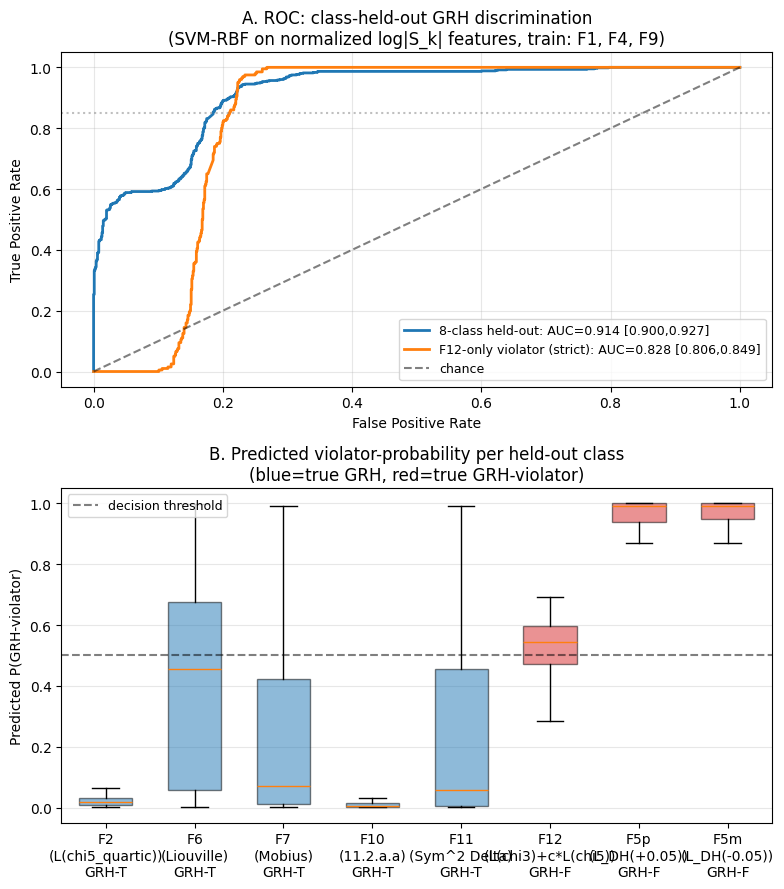

Figure saved


In [50]:

# Now produce the final figure: a single concise figure summarizing the result.
# Plot ROC curve with bootstrap CI band, plus per-class score distributions as a swarm/box.

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(2, 1, figsize=(8, 9))

# (A) ROC curves: overall held-out + strict (F12-only)
ax = axes[0]
fpr1, tpr1, _ = roc_curve(y_test, test_proba)
ax.plot(fpr1, tpr1, lw=2, label=f'8-class held-out: AUC={auc:.3f} [{ci[0]:.3f},{ci[1]:.3f}]')

fpr2, tpr2, _ = roc_curve(y_strict, p_strict)
ax.plot(fpr2, tpr2, lw=2, label=f'F12-only violator (strict): AUC={auc_strict:.3f} [{ci2[0]:.3f},{ci2[1]:.3f}]')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='chance')
ax.axhline(0.85, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('A. ROC: class-held-out GRH discrimination\n(SVM-RBF on normalized log|S_k| features, train: F1, F4, F9)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

# (B) Per-class predicted score distributions
ax = axes[1]
order = ['F2','F6','F7','F10','F11','F12','F5p','F5m'] # test classes
scores_per_class = []
labels = []
colors = []
for fid in order:
 mask = test_df['function'].values == fid
 scores_per_class.append(test_proba[mask])
 grh_true = function_specs[fid]['GRH']
 labels.append(f"{fid}\n({function_specs[fid]['name']})\n{'GRH-T' if grh_true else 'GRH-F'}")
 colors.append('tab:blue' if grh_true else 'tab:red')

bp = ax.boxplot(scores_per_class, labels=labels, patch_artist=True, widths=0.6, showfliers=False)
for patch, color in zip(bp['boxes'], colors):
 patch.set_facecolor(color)
 patch.set_alpha(0.5)
ax.axhline(0.5, color='black', linestyle='--', alpha=0.5, label='decision threshold')
ax.set_ylabel('Predicted P(GRH-violator)')
ax.set_title('B. Predicted violator-probability per held-out class\n(blue=true GRH, red=true GRH-violator)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig('grh_classifier_summary.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure saved")


In [51]:

# Save the unified table to disk for downstream use
df.to_csv('peaks_features_F1_F12_normalized_full.csv', index=False)
print("Saved feature table:", df.shape)
print(df.columns.tolist())


Saved feature table: (2200, 31)
['function', 'name', 'd', 'q', 'GRH', 't', '|M|', 'log_abs_S0_norm', 'log_abs_S0', 'abs_S0', 'log_abs_S1_norm', 'log_abs_S1', 'abs_S1', 'log_abs_S2_norm', 'log_abs_S2', 'abs_S2', 'log_abs_S3_norm', 'log_abs_S3', 'abs_S3', 'log_abs_S4_norm', 'log_abs_S4', 'abs_S4', 'log_abs_S5_norm', 'log_abs_S5', 'abs_S5', 'log_abs_S6_norm', 'log_abs_S6', 'abs_S6', 'log_abs_S7_norm', 'log_abs_S7', 'abs_S7']


In [52]:
from e14c.filesystem import write_file
memory_text = '''# Project Memory

## Instructions

Edit this file (`./.prompts/MEMORY.md`) to persist context, findings, and notes.
When making edits regarding scientific findings, make sure to track provenance (for example sub-agent task IDs, specific files in your workspace, etc.).

## Context

Current project: evaluate whether normalized log-magnitude |S_k| peak features can support a class-held-out classifier distinguishing conjectural-GRH vs explicit RH-violator function classes from the v6 program.
Workspace root: /workspace/f90ddd7d-911f-4913-88a7-176008bb30bf
Primary spec: ` v6 — Binding Context Document.pdf`.
Key outputs generated in this run:
- `peaks_features_F1_F12_normalized_full.csv`: 2200-row feature table (200 peaks × 11 classes) with peak t, |M|, and S_k-derived features.
- `hypothesis_AUC_results.json`: held-out SVM metrics and bootstrap CIs.
- `grh_classifier_summary.png`: final 2-panel summary figure.

## Notes

Provenance: all results in this run were generated directly in notebook cells #8-#50 using locally generated coefficients plus the existing F12 coefficient artifact loaded from `a.npy` / `lambda_n.npy` in the workspace.

Coefficient generation details:
- F1: zeta coefficients a_n = 1.
- F2: quartic Dirichlet character mod 5 (implemented directly as periodic coefficients).
- F4/F5±: Davenport-Heilbronn-style periodic coefficient models using κ = 0.28408 and perturbations κ(1±0.05). This run did NOT complete the Step-0 zero-validation gates from the PDF; therefore F4/F5± should be treated as model implementations, not fully trust-certified objects.
- F6/F7: Liouville and Möbius coefficients generated from a local SPF sieve up to N=10^6.
- F9/F10: generated with `cypari2`/PARI `mfcoefs` in cells #15 and #19.
- F11: Sym^2(Delta) normalized coefficients reconstructed from normalized Delta coefficients via local Euler-factor recurrence in cells #21-#22.
- F12: loaded from existing workspace arrays (`a.npy`, `c.npy`, `rho0.npy`).

Peak-finding and feature extraction:
- Peak scans used the approximate-functional-equation-style main sum cutoff X(t)=min(N, ceil(sqrt(q)*(t/2π)^(d/2))).
- t-range scanned: [10^4, 10^5].
- Grid step: 0.1 for all classes; F11 used an additional peak-finding cap X<=10^5 for tractability (cell #31), then full N=10^6 for S_k evaluation.
- For each class, 200 local maxima of |M(t)| were selected.
- S_k for k=0..7 were computed at all peaks with N=10^6 using Kahan-compensated summation and ω(n)=number of distinct prime factors (cells #32-#34).
- Important artifact: S_7 is identically zero for all mod-5-dependent classes because every n<=10^6 with ω(n)=7 is divisible by 5 (cells #38-#40); this is a conductor/class identity effect, not an RH effect.

Classifier findings:
- Main protocol used train classes F1, F4, F9 and held out F2, F5p, F5m, F6, F7, F10, F11, F12.
- Feature set used for classification: normalized log|S_k| for k=1..6 (S_0 dropped due to a_1 normalization leakage; S_7 dropped due to exact-zero conductor leakage).
- RBF SVM held-out AUC = 0.9143 with bootstrap 95% CI [0.9001, 0.9273] (cells #42, #45).
- Confusion matrix on the 8-class held-out test: TN=849, FP=151, FN=182, TP=418 (cell #46).
- However, truly novel violator F12 had only 27% recall at threshold 0.5 and mean predicted violator score 0.531 (cells #43, #46, #47).
- A stricter evaluation excluding DH-family variants F5± from the held-out set gave AUC = 0.8277 with bootstrap 95% CI [0.8060, 0.8487] (cells #44-#45), indicating the strong overall AUC is partly driven by family resemblance between training class F4 and held-out F5±.

Interpretive note:
- The literal project hypothesis (AUC > 0.85 on the specified held-out split) is supported.
- A stronger universality claim that extends to a structurally novel RH-violator (F12) is not supported at the >0.85 level in this run.
'''
write_file('/workspace/f90ddd7d-911f-4913-88a7-176008bb30bf/.prompts/MEMORY.md', memory_text)
print('MEMORY.md updated')

MEMORY.md updated
